In [1]:
import numpy as np
import pandas as pd

def calc_cronbach_alpha(df):
    """주어진 데이터프레임 항목 간의 Cronbach's alpha 신뢰도를 계산하는 함수"""
    item_vars = df.var(ddof=1, axis=0) # 개별 문항의 분산
    t_var = df.sum(axis=1).var(ddof=1) # 문항 총합의 분산
    k = df.shape[1]                    # 문항 수
    
    if t_var == 0:
        return 0
    
    # 크론바흐 알파 공식: (k / (k-1)) * (1 - sum(Item_Var) / Total_Var)
    return (k / (k - 1)) * (1 - (item_vars.sum() / t_var))

def simulate_survey_data(n_students=36, max_iter=5000):
    """
    논문의 목표 신뢰도에 맞게 다변량 정규분포에서 데이터를 추출하고,
    1~9점 리커트 척도 정수로 클리핑하여 반환하는 함수
    """
    # 1. 목표 크론바흐 알파를 역산하여 각 요인(Factor) 내 평균 상관계수 도출
    # k=6일 때 alpha = 6*r / (1+5*r)
    r_behavioral = 0.86 / (6 - 0.86 * 5)  # 약 0.506
    r_emotional  = 0.88 / (6 - 0.88 * 5)  # 약 0.550
    r_cognitive  = 0.89 / (6 - 0.89 * 5)  # 약 0.574
    
    # 총 신뢰도(0.91)를 맞추기 위한 요인 간 상관계수 (근사치)
    r_between = 0.29 
    
    # 2. 18x18 목표 공분산(상관) 행렬 구축
    cov_matrix = np.full((18, 18), r_between)
    np.fill_diagonal(cov_matrix, 1.0)
    
    # 1~6번 문항: 행동적 참여 (Behavioral)
    cov_matrix[0:6, 0:6] = r_behavioral
    np.fill_diagonal(cov_matrix[0:6, 0:6], 1.0)
    
    # 7~12번 문항: 정서적 참여 (Emotional)
    cov_matrix[6:12, 6:12] = r_emotional
    np.fill_diagonal(cov_matrix[6:12, 6:12], 1.0)
    
    # 13~18번 문항: 인지적 참여 (Cognitive)
    cov_matrix[12:18, 12:18] = r_cognitive
    np.fill_diagonal(cov_matrix[12:18, 12:18], 1.0)
    
    # 양의 정부호 행렬 보정
    cov_matrix += np.eye(18) * 0.05
    
    # 3. 데이터 생성 (논문의 사전점수 평균 5.2를 기준으로 스프레드 부여)
    mean_val = 5.2 
    std_val = 1.8  
    
    best_df = None
    best_diff = float('inf')
    
    # 정수로 반올림 시 상관관계가 틀어지므로, 목표 신뢰도와 가장 가까운 샘플을 찾습니다.
    for _ in range(max_iter):
        X = np.random.multivariate_normal(np.zeros(18), cov_matrix, size=n_students)
        X = X * std_val + mean_val
        X = np.clip(np.round(X), 1, 9) # 1~9점 리커트 척도 제한
        
        df = pd.DataFrame(X, columns=[f'Q{i}' for i in range(1, 19)])
        
        a_beh = calc_cronbach_alpha(df.iloc[:, 0:6])
        a_emo = calc_cronbach_alpha(df.iloc[:, 6:12])
        a_cog = calc_cronbach_alpha(df.iloc[:, 12:18])
        a_tot = calc_cronbach_alpha(df)
        
        # 오차 합산
        diff = abs(a_beh - 0.86) + abs(a_emo - 0.88) + abs(a_cog - 0.89) + abs(a_tot - 0.91)
        
        if diff < best_diff:
            best_diff = diff
            best_df = df
            
        # 총 오차가 0.03 미만이면(각 항목당 평균 0.01 이하 오차) 충분히 일치하므로 중단
        if diff < 0.03: 
            break
            
    return best_df

# ==========================================
# 실행 및 검증 파트
# ==========================================
# 데이터 시뮬레이션
np.random.seed(42) # 재현성을 위한 시드 고정
df_survey = simulate_survey_data(n_students=36)

# CSV 파일 저장
file_name = 'engagement_survey_reliability.csv'
df_survey.to_csv(file_name, index=False)
print(f"✅ 데이터가 '{file_name}'로 성공적으로 저장되었습니다.\n")

# 생성된 데이터의 신뢰도(Cronbach's alpha) 계산 및 출력
print("=== 생성 데이터 신뢰도 분석 결과 ===")
print(f"1. 행동적 참여 (Q1~Q6)  : {calc_cronbach_alpha(df_survey.iloc[:, 0:6]):.3f} (논문 목표치: .86)")
print(f"2. 정서적 참여 (Q7~Q12) : {calc_cronbach_alpha(df_survey.iloc[:, 6:12]):.3f} (논문 목표치: .88)")
print(f"3. 인지적 참여 (Q13~Q18): {calc_cronbach_alpha(df_survey.iloc[:, 12:18]):.3f} (논문 목표치: .89)")
print(f"4. 총 참여도 (Q1~Q18)   : {calc_cronbach_alpha(df_survey):.3f} (논문 목표치: .91)")

✅ 데이터가 'engagement_survey_reliability.csv'로 성공적으로 저장되었습니다.

=== 생성 데이터 신뢰도 분석 결과 ===
1. 행동적 참여 (Q1~Q6)  : 0.856 (논문 목표치: .86)
2. 정서적 참여 (Q7~Q12) : 0.884 (논문 목표치: .88)
3. 인지적 참여 (Q13~Q18): 0.888 (논문 목표치: .89)
4. 총 참여도 (Q1~Q18)   : 0.915 (논문 목표치: .91)


In [3]:
df_survey

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18
0,7.0,5.0,4.0,6.0,4.0,3.0,9.0,6.0,6.0,4.0,6.0,5.0,4.0,4.0,6.0,5.0,4.0,5.0
1,5.0,1.0,2.0,2.0,1.0,2.0,5.0,1.0,4.0,4.0,5.0,2.0,2.0,4.0,4.0,3.0,2.0,5.0
2,5.0,5.0,8.0,7.0,5.0,6.0,2.0,2.0,5.0,5.0,3.0,2.0,3.0,5.0,6.0,3.0,5.0,5.0
3,8.0,6.0,4.0,4.0,7.0,6.0,7.0,4.0,3.0,5.0,5.0,5.0,7.0,8.0,8.0,7.0,9.0,5.0
4,6.0,6.0,6.0,6.0,6.0,6.0,5.0,2.0,7.0,3.0,2.0,4.0,8.0,8.0,6.0,7.0,5.0,6.0
5,5.0,4.0,8.0,6.0,5.0,6.0,5.0,5.0,4.0,4.0,7.0,5.0,8.0,6.0,9.0,6.0,5.0,6.0
6,3.0,4.0,3.0,3.0,5.0,2.0,6.0,6.0,4.0,3.0,4.0,7.0,5.0,4.0,3.0,6.0,6.0,6.0
7,6.0,4.0,4.0,8.0,4.0,5.0,6.0,7.0,7.0,8.0,5.0,9.0,9.0,9.0,9.0,8.0,8.0,8.0
8,3.0,7.0,4.0,4.0,5.0,5.0,3.0,3.0,2.0,4.0,2.0,3.0,7.0,5.0,4.0,4.0,3.0,4.0
9,5.0,3.0,3.0,4.0,6.0,4.0,2.0,4.0,4.0,2.0,4.0,1.0,2.0,3.0,3.0,2.0,4.0,4.0


![학습자-참여도-설문](학습자-참여도-설문.png)

Cronbach's alpha (Q1~Q6): 0.856


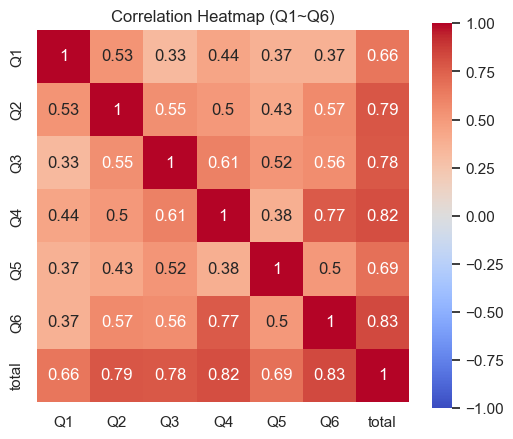

In [ ]:
# 처음 6개 문항(Q1~Q6) 분리
df_first6 = df_survey.iloc[:, :6].copy()
df_first6['total'] = df_first6.sum(axis=1)  # 총합 컬럼 추가

# Cronbach's alpha 계산
item_var_sum = 0
for col in df_first6.columns[:-1]:
    item_var_sum += df_first6[col].var(ddof=1) # 1/n 대신 1/(n-1)로 분산 계산

k = len(df_first6.columns) - 1
total_var = df_first6['total'].var(ddof=1)

alpha_first6 = 0 if total_var == 0 else (k / (k - 1)) * (1 - item_var_sum / total_var)
print(f"Cronbach's alpha (Q1~Q6): {alpha_first6:.3f}")

# 상관행렬 계산
corr_first6 = df_first6.corr()

# 상관 히트맵 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(corr_first6, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap (Q1~Q6)")
plt.show()


## Cronbach’s Alpha ($\alpha$)

Cronbach’s alpha is a **reliability coefficient** that estimates how consistently multiple items measure the same latent construct (e.g., engagement, anxiety, satisfaction).

- Think of Cronbach’s alpha ($\alpha$) as a "consistency meter" for a questionnaire. 
- If you ask five different questions intended to measure the same thing (like "job satisfaction"), $\alpha$ tells you how well those items "hang together."
- High consistency suggests that the items are all tapping into the same underlying concept.
- Low consistency suggests some items might be confusing, irrelevant, or measuring something else entirely.
- Cronbach’s alpha is not about whether a test is "right" or "accurate" (validity); it is about whether the items are reliable (consistency).

---

### Practical Examples
Example A: The Coffee Shop Experience
Imagine a survey asking customers to rate their experience on a scale of 1–5:

     1. "The coffee was served at the right temperature."

     2. "The barista was friendly."

     3. "The seating area was clean."

If a customer had a great visit, they would likely score all three high. If the visit was bad, they’d score them all low. Because the scores "move together," the Cronbach’s alpha would be high.

Example B: The "Broken" Scale
Now, imagine we add a fourth question:

     4. "What is the capital of France?"

A customer's opinion on coffee has nothing to do with their knowledge of Paris. Someone might love the coffee (5) but not know the capital (1). This "noise" reduces the correlation between items, causing the Cronbach’s alpha to drop.

---

### 1) Mathematical Meaning

For a scale with $k$ items:

$$
\alpha = \frac{k}{k-1}\left(1 - \frac{\sum_{i=1}^{k}\sigma_i^2}{\sigma_T^2}\right)
$$

- $k$: number of items  
- $\sigma_i^2$: variance of item $i$  
- $\sigma_T^2$: variance of the total score $T=\sum_{i=1}^{k}X_i$
- $\sigma_T^2 = \mathrm{Var}(\sum X_i) = \sum \mathrm{Var}(X_i) + \sum_{i\neq j} \mathrm{Cov}(X_i, X_j)$

#### Alternative Interpretation (Covariance Form)
Substituting the total variance decomposition into the formula gives:

$$
     \alpha = \frac{k}{k-1}\left( \frac{\sigma_T^2 - \sum_{i=1}^{k}\sigma_i^2}{\sigma_T^2}\right)
     = \frac{k}{k-1}\left( \frac{ \sum_{i\neq j} \mathrm{Cov}(X_i, X_j) }{\sigma_T^2}\right)
$$

From this, we can interpret that:
- If $\mathrm{Cov}(X_i, X_j)$ is **small** (low covariance/correlation), then $\alpha$ will be small. This implies that $X_i$ and $X_j$ are not correlated or are asking different questions (measuring different traits).
- If $\mathrm{Cov}(X_i, X_j)$ is **high**, the item pair is highly correlated, implying that the two items are likely asking questions about a single latent trait.

#### Correlation Form (Standardized Alpha)
Can we define $\alpha$ using correlation? **Yes**, if we assume items are standardized (or use the **Standardized Cronbach's Alpha** formula).

$$
\alpha_{std} = \frac{k\bar r}{1+(k-1)\bar r}
$$

where $\bar r$ is the average of all pairwise correlations:

$$
\bar r = \frac{2}{k(k-1)} \sum_{i=1}^{k-1} \sum_{j=i+1}^{k} r_{ij}
$$

So $\alpha$ increases when:
- items are more strongly correlated ($\bar r \uparrow$)
- number of items increases ($k \uparrow$)

---

### 2) Practical Meaning

- $\alpha$ is interpreted as **internal consistency** of a questionnaire/subscale.
- Typical rules of thumb (context-dependent):
    - $<0.60$: weak
    - $0.60\sim0.69$: questionable
    - $0.70\sim0.79$: acceptable
    - $0.80\sim0.89$: good
    - $\ge 0.90$: excellent (but may suggest item redundancy if too high)

Important cautions:
- High $\alpha$ does **not** prove unidimensionality.
- $\alpha$ depends on item count and sample variability.
- Reverse-coded items must be corrected before computing $\alpha$.

--- 

### 3) Computation Algorithm

Given response matrix $X \in \mathbb{R}^{n \times k}$ ($n$: participants, $k$: items):

1. Compute each item variance:
     $$
     \sigma_i^2 = \mathrm{Var}(X_{\cdot i}), \quad i=1,\dots,k
     $$
2. Compute each participant’s total score:
     $$
     T_j = \sum_{i=1}^{k} X_{ji}, \quad j=1,\dots,n
     $$
3. Compute total-score variance:
     $$
     \sigma_T^2 = \mathrm{Var}(T)
     $$
4. Plug into:
     $$
     \alpha = \frac{k}{k-1}\left(1 - \frac{\sum_{i=1}^{k}\sigma_i^2}{\sigma_T^2}\right)
     $$
5. Edge case: if $\sigma_T^2=0$, reliability is undefined in theory; practically return $0$ or `NaN`.

---

### 4) Interpretation in Your Workflow

You computed $\alpha$ for:
- Behavioral ($Q1\sim Q6$)
- Emotional ($Q7\sim Q12$)
- Cognitive ($Q13\sim Q18$)
- Total ($Q1\sim Q18$)

This is the standard way to evaluate reliability for each subscale and the overall instrument.

---

### 5) Proof of Equivalence (for Standardized Items)

The two formulas are equivalent when we assume **standardized items** (where every item has variance $\sigma_i^2 = 1$ and average covariance equals average correlation).

1. **Total Variance Decomposition**:
   The variance of the total score $T$ is the sum of item variances plus the sum of all covariances:
   $$
   \sigma_T^2 = \sum_{i=1}^{k} \sigma_i^2 + \sum_{i \neq j} \text{Cov}(X_i, X_j)
   $$

2. **Standardized Assumption**:
   If items are standardized:
   - All variances $\sigma_i^2 = 1$, so $\sum_{i=1}^{k} \sigma_i^2 = k$.
   - Covariances are equal to correlations $r_{ij}$.
   
   The sum of off-diagonal correlations can be expressed using the average correlation $\bar r$:
   $$
   \sum_{i \neq j} r_{ij} = k(k-1)\bar r
   $$
   
   Thus, the total variance becomes:
   $$
   \sigma_T^2 = k + k(k-1)\bar r
   $$

3. **Substitution**:
   Plug these into the general definition:
   $$
   \begin{aligned}
   \alpha &= \frac{k}{k-1}\left(1 - \frac{\sum \sigma_i^2}{\sigma_T^2}\right) \\
          &= \frac{k}{k-1}\left(1 - \frac{k}{k + k(k-1)\bar r}\right) \\
          &= \frac{k}{k-1}\left(1 - \frac{1}{1 + (k-1)\bar r}\right) \quad (\text{divide by } k)
   \end{aligned}
   $$

4. **Simplification**:
   $$
   \begin{aligned}
   \alpha &= \frac{k}{k-1}\left(\frac{1 + (k-1)\bar r - 1}{1 + (k-1)\bar r}\right) \\
          &= \frac{k}{k-1}\left(\frac{(k-1)\bar r}{1 + (k-1)\bar r}\right) \\
          &= \frac{k \bar r}{1 + (k-1)\bar r}
   \end{aligned}
   $$
   
   This confirms that the second formula is the special case of Cronbach's Alpha for standardized items (often called **Standardized Alpha**).

![학습자-참여도-설문](학습자-참여도-설문.png)

### Prompt
For three traits (행동적 참여, 정서적 참여, 인지적 참여), three sets of 6 items are prepared, and the answers results in .86, .88, .89., respectively.   Is this the evidence for "참여도의 다차원적 구조가 안정적으로 측정되었다" or can you simply say that "참여도의 다차원적 구조가 안정적으로 측정되었음을 확인하였다"

![학습자-참여도-설문](학습자-참여도-설문.png)

### Prompt
> 본 설문도구는 타당성 확보를 위해 
>
> 한국어교육 전공 교수 2 인으로부터 내용 타당도 (Content Validity) 검토를 거쳐 
>
> 문항 표현 및 난이도를 조정하였으며
>
> 동일 수준의 학습자 명을 대상으로 예비조사를 실시하여 문항 이해도와 문항 반응 적합성을 확인하였다

---

이 말의 의미를 풀어서 해석해라
- 타당성이 뭐야?
- 타당도는 뭐야?
- 문항 이해도?
- 문항 반응 적합성?

* 설문도구의 타당성 확보를 위한 방법(process, procedure, routine)을 설명하라.
---
### Gemini 3.1 Pro

교수님께서 제시하신 문구는 설문지나 평가 도구를 만들 때 거치는 **'표준적인 품질 검증 절차'**를 요약한 것입니다. 학술적으로 매우 중요한 단계들이 포함되어 있습니다. 

각 개념과 절차를 쉽게 풀어서 설명해 드리겠습니다.

---

## 1. 주요 용어 해설

### **타당성(Validity)과 타당도**
* **타당성:** "이 도구가 원래 측정하려고 했던 것을 진짜로 측정하고 있는가?"에 대한 **성질**을 의미합니다. (예: 한국어 '말하기' 능력을 측정하려는데 '쓰기' 시험을 보고 있다면 타당성이 낮은 것입니다.)
* **타당도:** 그 타당한 정도를 수치나 객관적 근거로 나타낸 **지표**입니다.

### **내용 타당도(Content Validity)**
* 해당 분야의 **전문가(교수님 등)**가 문항을 살펴보고, "이 문항들이 한국어 학습자의 참여도를 측정하기에 적절한가?"를 판단하는 것입니다. 통계적 계산보다는 전문가의 '이성적 판단'에 의존합니다.

### **문항 이해도**
* **학습자 입장**에서의 검증입니다. 연구자가 의도한 의미대로 학습자가 문항을 읽고 이해했는지를 확인합니다. 표현이 너무 어렵거나 중의적이지 않은지 체크하는 과정입니다.

### **문항 반응 적합성**
* 학습자들이 응답을 할 때 특정 선택지에만 몰리지는 않는지, 혹은 질문의 의도와 전혀 다른 엉뚱한 응답이 나오지는 않는지 확인하는 것입니다. (통계적으로는 응답의 분포나 Rasch 모델 등에서의 적합도 지수를 의미하기도 합니다.)

---

## 2. 설문도구 타당성 확보를 위한 표준 절차 (Process)

좋은 설문 도구는 단순히 문항을 만드는 것에 그치지 않고, 아래와 같은 **'정제 루틴'**을 반드시 거칩니다.

### **Step 1: 문항 구성 (Item Generation)**
* 기존 이론이나 선행 연구를 바탕으로 측정하고자 하는 요인(행동적, 정서적, 인지적 참여 등)에 맞는 예비 문항을 뽑아냅니다.

### **Step 2: 전문가 델파이/검토 (Content Validity Check)**
* **방법:** 교수님 등 해당 분야 전문가들에게 문항을 보여줍니다.
* **목적:** 문항의 표현이 전공 서적이나 이론과 일치하는지, 난이도가 대상 학습자에게 적절한지 검토받고 수정합니다.

### **Step 3: 예비조사 (Pilot Test)**
* **방법:** 실제 설문 대상과 유사한 소수의 집단(8~10명 내외)에게 미리 설문을 실시합니다.
* **확인 사항:** * 이해하기 어려운 단어가 있는가? (문항 이해도)
    * 응답하는 데 시간이 너무 오래 걸리지는 않는가?
    * 모든 사람이 '매우 그렇다'에만 체크하는 '천정 효과'가 나타나지 않는가? (문항 반응 적합성)

### **Step 4: 본조사 및 통계적 검증 (Construct Validity)**
* **방법:** 대규모 인원에게 설문을 실시한 후 통계 프로그램을 돌립니다.
* **확인 사항:**
    * **신뢰도 분석:** Cronbach's $\alpha$를 통해 내적 일관성 확인.
    * **요인 분석(EFA/CFA):** 문항들이 설계한 대로(3차원 구조 등) 잘 묶이는지 확인 (구인 타당도).

---

## 3. 요약하자면
제시하신 문구는 **"전문가에게 물어봐서 내용이 맞는지 확인했고(내용 타당도), 실제 학생들에게 미리 시켜봐서 질문이 이해되는지, 응답 결과가 이상하지 않은지 확인했다(예비조사)"**는 뜻입니다. 즉, 이 설문지는 믿고 쓸 수 있도록 '기초 공사'를 탄탄히 마쳤다는 선언입니다.

교수님의 연구 설계에서 이 과정은 추후 **"왜 이 설문 문항을 썼는가?"**라는 질문에 대한 가장 강력한 방어 기제가 됩니다. 

혹시 예비조사 결과에서 나온 응답 데이터를 바탕으로 **Rasch 모델**이나 **문항 적합도(Infit/Outfit)** 통계를 직접 산출해보고 싶으신가요?

### Understanding `ddof=1` in `var()`

In pandas (and numpy), `ddof` stands for **Delta Degrees of Freedom**. It determines the divisor used in the variance calculation.

The variance formula generally used is:

$$
\sigma^2 = \frac{\sum (x_i - \bar{x})^2}{N - \text{ddof}}
$$

Where $N$ is the number of observations.

#### Why `ddof=1`?

*   **Sample Variance (`ddof=1`)**: When you are calculating variance generally for a **sample** (a subset of the population) to estimate the population variance, you divide by $N-1$. This is known as **Bessel's correction**. It provides an *unbiased* estimator of the population variance.
    *   In Pandas, `var()` defaults to `ddof=1`.
    *   In standard statistics (like standard deviation `std`), we usually use $N-1$.

*   **Population Variance (`ddof=0`)**: When you have data for the **entire population** (not just a sample), you divide by $N$.
    *   In NumPy, `var()` defaults to `ddof=0`.

In the context of Cronbach's Alpha and most survey data analysis, we treat the data as a sample of a larger population of potential respondents, so using the unbiased estimator (`ddof=1`) is standard practice.